<a href="https://colab.research.google.com/github/tylerjohnbecker/Nonlinear_and_Data_Driven_Estimation/blob/main/BouncingBall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
import math
from scipy.integrate import odeint

In [94]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

In [95]:
try:
    import casadi as ca
except:
    !pip install casadi
    import casadi as ca

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

# Parameters for the Linear System (Unknowns lead to nonlinearity)

In [96]:
m = 1
r = .5
e = .2
mu = .4
delta_t = .2
Im = 0.4 * m * r ** 2
g=-9.81

# In-Air Dynamics for the Bouncing Ball

In [97]:
def f_in_air(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (7,)
    u_vec : array-like, shape (2,)
    m : float, shape (1,)
        mass of the ball
    g : float, shape (1,)
        acceleration due to gravity
    Im : float, shape (1,)
        Inertia for the ball
    r : float, shape (1,)
        radius of the ball
    e : float, shape (1,)
        coefficient of restitution
    mu : float, shape (1,)
        coefficient of friction

    Returns:
    x_dot : numpy array, shape (7,)
        Time derivative of state vector
    """

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 0,
                                 z_dot,
                                 g,
                                 theta_dot,
                                 0])

    # f1 component: multiplied by control u1
    f1_contribution = f_x * np.array([0,
                                     1 / m,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control u2
    f2_contribution = f_z * np.array([0,
                                     0,
                                     0,
                                     1 / m ,
                                     0,
                                     0])

    # f3 component: multiplied by control u3
    f3_contribution = tor * np.array([0,
                                     0,
                                     0,
                                     0,
                                     0,
                                     1 / Im])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution + f3_contribution

    return x_dot_vec

# Impact Dynamics of the Ball

In [98]:
def f_impact(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu, stiffness=100, damping=100):
    """
    Continuous contact dynamics using compliant contact model.

    This models the ground as a spring-damper system, which is
    continuous and differentiable.

    Parameters:
    stiffness: contact stiffness (N/m) - higher = more rigid ground
    damping: contact damping (N·s/m) - related to coefficient of restitution
    """
    x_dot = x_vec[1]
    z_dot = x_vec[3]
    theta_dot = x_vec[5]
    z = x_vec[2]

    f_x, f_z, tau = u_vec[0], u_vec[1], u_vec[2]

    # Penetration depth (positive when in contact)
    penetration = r - z

    # Normal force (Hunt-Crossley contact model)
    # Only active when penetration > 0
    if penetration > 0:
        # Spring force + damping force
        f_normal = stiffness * penetration - damping * penetration * z_dot
        f_normal = ca.if_else(0 > f_normal, 0, f_normal)  # No pulling force
    else:
        f_normal = 0

    # Tangential velocity at contact point (bottom of ball)
    v_contact = x_dot - r * theta_dot

    # Friction force opposes contact point motion
    # If v_contact > 0 (sliding right), friction acts left (negative)
    # If v_contact < 0 (sliding left), friction acts right (positive)
    v_threshold = 0.1  # m/s - smoothing parameter
    friction_direction = np.tanh(v_contact / v_threshold)
    f_friction_ideal = -mu * f_normal * friction_direction

    # Cap friction force to prevent unrealistic accelerations
    max_friction_force = 1.0  # Newtons - tune based on your ball mass
    f_friction = np.clip(f_friction_ideal, -max_friction_force, max_friction_force)

    # if v_contact > .5:
    #     print(f"v_contact: {v_contact} | rot: {r * theta_dot}")
    #     print(f"z: {z} | N: {f_normal } | fric: {f_friction} | dir: {friction_direction}")

    # Equations of motion
    x_dot_vec = np.array([
        x_dot,
        (f_x + f_friction) / m,
        z_dot,
        -g + (f_z + f_normal) / m,
        theta_dot,
        (tau - r * f_friction) / Im
    ])

    return x_dot_vec

In [99]:
# Better transition function - starts transition earlier
def smooth_transition_improved(z, r, width=0.05):
    """
    Improved transition that activates contact mode earlier.

    Returns value in [0, 1]:
    - ~0 when deeply in contact (z < r - width)
    - ~0.5 when z = r
    - ~1 when clearly in air (z > r + width)
    """
    # Sigmoid centered slightly ABOVE ground level
    # This ensures contact model stays active during bouncing
    center = r + width
    return 1 / (1 + np.exp(-(z - center) / width))

In [100]:
def estimate_damping_from_cor(e, m, stiffness):

    # Calculate damping ratio from coefficient of restitution
    ln_e = np.log(e)

    xi = np.sqrt(ln_e**2 / (np.pi**2 + ln_e**2))

    # For very low e, increase damping further
    correction = 1.0 + (0.3 - e) * 2.0

    xi = ca.if_else(e < .3, xi, xi * correction);

    # Calculate critical damping
    damping = 2 * xi * np.sqrt(m * stiffness)

    damping = ca.if_else(ca.fabs(e - 1.0) < 1e-6, 0.0, damping);

    return np.array([damping]).flatten()[0]

In [101]:
def f_sigm_combined(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu, stiffness=100, transition_width=0.05):
    """
    Combined dynamics with smooth transition.
    """
    alpha = smooth_transition_improved(x_vec[2], r, transition_width)

    f_air = f_in_air(x_vec, u_vec, m, g, Im, r)
    f_cont = f_impact(x_vec, u_vec, m, g, Im, r, e, mu, stiffness, estimate_damping_from_cor(e, m, stiffness))

    # print(f"  air_x_accel={f_air[1]}, contact_x_accel={f_cont[1]}, blended_x_accel={(alpha * f_air + (1 - alpha) * f_cont)[1]}")

    return alpha * f_air + (1 - alpha) * f_cont

# ODE wrapper for the In-Air Dynamics

In [102]:
def f_ode(x_vec, tsim, u_func, f):
    '''
    Wrap dynamics function so it can be used with odeint.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector
    tsim : float
        Current time step
    u_func: function
        Control function
    f: function
        Continuous time dynamics function

    Returns:
    x_dot_vec : numpy array, shape (7,)
        Time derivative of state vector
    '''
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)

    # print(f'x_dot_val: {x_dot_vec[1]}')

    return x_dot_vec

# Basic Ball Bouncing Controls
When the ball is above 3 meters we accelerate it downwards to ensure that it continues bouncing

In [103]:
def u_func(x_vec, tsim, m=m, g=g, r=r, Im=Im, e=e, mu=mu):
    '''
    Simple controller that moves the drone right, so I can observe it bouncing.
    '''
    x_dot_desired = 1
    x_dot = x_vec[1]

    err_x = max( 0, x_dot_desired - x_dot )

    ctrl_x = 10 * err_x

    theta_dot_desired = -1
    theta_dot = x_vec[5]

    err_theta = theta_dot_desired - theta_dot

    ctrl_theta = 10 * err_theta

    z_dot_desired = -5
    z_dot = x_vec[3]

    err_z = min( 0, z_dot_desired - z_dot )
    ctrl_z = 10 * err_z

    # if x_vec[2] > 1:
    #    return [0, ctrl_z, 0]

    return [0, -1, 1]

In [104]:
delta_t = .02
tsim = np.arange(0, 8.0, step=delta_t)

# Simulate the dynamics using ODE int

In [105]:
x0 = np.array([0, 1, 4.0, 0, 0, 0])

# result = odeint(f_ode, x0, tsim, args=(u_func, f_sigm_combined) )

In [106]:
# sol = np.array(result)

# fig = plt.figure()
# ax = fig.add_subplot(111)
# ax.plot(sol[:, 0], sol[:, 2], '.')
# ax.set_xlabel('x pos')
# ax.set_ylabel('z pos')

# fig3 = plt.figure()
# ax3 = fig3.add_subplot(111)
# ax3.plot(tsim, sol[:,1])
# ax3.set_xlabel('time')
# ax3.set_ylabel('x_dot')
# fig2 = plt.figure()
# ax2 = fig2.add_subplot(111)
# ax2.plot(tsim, sol[:,2])
# ax2.set_xlabel('time')
# ax2.set_ylabel('z')
# fig3 = plt.figure()
# ax3 = fig3.add_subplot(111)
# ax3.plot(tsim, sol[:,3])
# ax3.set_xlabel('time')
# ax3.set_ylabel('z_dot')
# fig3 = plt.figure()
# ax3 = fig3.add_subplot(111)
# ax3.plot(tsim, sol[:,5])
# ax3.set_xlabel('time')
# ax3.set_ylabel('theta_dot')

### Nonlinear dynamics of the system

In [107]:
measurement_noise_stds = { 'x' : .2, 'z': .2, 'theta_dot': .1 }

In [108]:
def h_three_states(x_vec, u_vec):
    # Return measurement
    return np.array([x_vec[0], x_vec[2], x_vec[5]])

In [109]:
def f_in_air_nonlinear(x_vec, u_vec, g=g, Im=Im, r=r ):
    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    m = x_vec[6]
    e = x_vec[7]
    mu = x_vec[8]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 0,
                                 z_dot,
                                 g,
                                 theta_dot,
                                 0,
                                 0,
                                 0,
                                 0])

    # f1 component: multiplied by control u1
    f_other_contribution = np.array([0,
                                     f_x / m,
                                     0,
                                     f_z / m,
                                     0,
                                     tor / Im,
                                     0,
                                     0,
                                     0])

    x_dot_vec = f0_contribution + f_other_contribution

    return x_dot_vec

In [110]:
def f_impact_nonlinear(x_vec, u_vec, g=g, Im=Im, r=r, stiffness=100, damping=100):
    x_dot = x_vec[1]
    z_dot = x_vec[3]
    theta_dot = x_vec[5]
    z = x_vec[2]

    m = x_vec[6]
    e = x_vec[7]
    mu = x_vec[8]

    f_x, f_z, tau = u_vec[0], u_vec[1], u_vec[2]

    # Penetration depth (positive when in contact)
    penetration = r - z

    # Normal force (Hunt-Crossley contact model)
    f_normal = stiffness * penetration - damping * penetration * z_dot
    f_normal = np.array([ca.if_else(f_normal > 0, f_normal, 0)]).flatten()[0]
    f_normal = np.array([ca.if_else(penetration > 0, f_normal, 0)]).flatten()[0]

    # Tangential velocity at contact point (bottom of ball)
    v_contact = x_dot - r * theta_dot

    # Friction force opposes contact point motion
    v_threshold = 0.1  # m/s - smoothing parameter
    friction_direction = np.tanh(v_contact / v_threshold)
    f_friction_ideal = -mu * f_normal * friction_direction

    # Cap friction force to prevent unrealistic accelerations
    max_friction_force = 1.0  # Newtons - tune based on your ball mass

    friction_sign = np.sign(f_friction_ideal)
    f_friction_ideal = friction_sign * f_friction_ideal

    f_friction = np.array([ca.if_else(f_friction_ideal > max_friction_force, max_friction_force, f_friction_ideal)]).flatten()[0] * friction_sign

    # Equations of motion
    x_dot_vec = np.array([
        x_dot,
        (f_x + f_friction) / m,
        z_dot,
        -g + (f_z + f_normal) / m,
        theta_dot,
        (tau - r * f_friction) / Im,
        0,
        0,
        0
    ])

    return x_dot_vec

In [111]:
def f_sigm_combined_nonlinear(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu, stiffness=100, transition_width=0.05):
    """
    Combined dynamics with smooth transition.
    """
    alpha = smooth_transition_improved(x_vec[2], r, transition_width)

    f_air = f_in_air_nonlinear(x_vec, u_vec, g, Im, r)
    f_cont = f_impact_nonlinear(x_vec, u_vec,g, Im, r, stiffness, estimate_damping_from_cor(x_vec[7], x_vec[6], stiffness))

    return alpha * f_air + (1 - alpha) * f_cont

In [112]:
class BouncingBallController:
    """
    Controller to make the ball bounce back and forth.

    Strategy:
    - When above 1m: apply forces to move horizontally and maintain height
    - When below 1m: no control (let natural dynamics/friction work)
    - Oscillate between left and right targets
    """

    def __init__(self,
                 target_bounce_height=1.5,  # Desired peak height (m)
                 target_x_amplitude=2.0,     # How far left/right (m)
                 oscillation_period=3.0,     # Time for full cycle (s)
                 control_threshold=1.0,      # No control below this (m)
                 push_down_height=1.3,       # Start pushing down at this height (m)
                 m=0.5,
                 g=9.81,
                 Im=0.002,
                 r=0.1):

        self.target_bounce_height = target_bounce_height
        self.target_x_amplitude = target_x_amplitude
        self.oscillation_period = oscillation_period
        self.control_threshold = control_threshold
        self.push_down_height = push_down_height
        self.m = m
        self.g = g
        self.Im = Im
        self.r = r

        # Horizontal control gains
        self.K_p_x = 25.0
        self.K_d_x = 15.0

        # Rotation control gains (keep upright)
        self.K_p_theta = 10.0
        self.K_d_theta = 5.0

        # Downward push force
        self.push_force = 6.0  # Additional downward force (N)

        # Control limits
        self.max_f_x = 50.0
        self.max_f_z = 100.0
        self.max_tau = 5.0

        # State tracking
        self.last_z = None
        self.last_z_dot = None

    def get_target_x(self, t):
        """
        Get desired horizontal position as function of time.
        Oscillates sinusoidally between -amplitude and +amplitude.
        """
        omega = 2 * np.pi / self.oscillation_period
        return self.target_x_amplitude * np.sin(omega * t)

    def get_target_x_dot(self, t):
        """
        Get desired horizontal velocity (derivative of target position).
        """
        omega = 2 * np.pi / self.oscillation_period
        return self.target_x_amplitude * omega * np.cos(omega * t)

    def __call__(self, x_vec, t):
        """
        Compute control inputs based on current state.

        Parameters:
        -----------
        t : float
            Current time (s)
        x_vec : array, shape (6,)
            State vector [x, ẋ, z, ż, θ, θ̇]

        Returns:
        --------
        u : array, shape (3,)
            Control vector [f_x, f_z, τ]
        """
        x = x_vec[0]
        x_dot = x_vec[1]
        z = x_vec[2]
        z_dot = x_vec[3]
        theta = x_vec[4]
        theta_dot = x_vec[5]

        # Below control threshold: no control
        if z < self.control_threshold:
            self.last_z = z
            self.last_z_dot = z_dot
            return np.array([0.0, 0.0, 0.0])

        # --- Horizontal Control ---
        x_desired = self.get_target_x(t)
        x_dot_desired = self.get_target_x_dot(t)

        x_error = x_desired - x
        x_dot_error = x_dot_desired - x_dot

        f_x = self.K_p_x * x_error + self.K_d_x * x_dot_error

        # --- Vertical Control ---
        # Strategy: push down when high, let bounce happen naturally

        if z_dot > 0:
            # Ball is rising - let it rise naturally (no force)
            f_z = 0.0
        elif z > self.push_down_height:
            # Ball is high and falling - push it down harder
            f_z = -self.push_force  # Negative = downward
        else:
            # Ball is lower - let gravity do the work
            f_z = 0.0

        # --- Rotation Control ---
        theta_error = 0.0 - theta
        theta_dot_error = 0.0 - theta_dot

        tau = self.K_p_theta * theta_error + self.K_d_theta * theta_dot_error

        # --- Apply Limits ---
        f_x = np.clip(f_x, -self.max_f_x, self.max_f_x)
        f_z = np.clip(f_z, -self.max_f_z, self.max_f_z)
        tau = np.clip(tau, -self.max_tau, self.max_tau)

        self.last_z = z
        self.last_z_dot = z_dot

        return np.array([f_x, f_z, tau])

In [113]:
left_right_controller = None

In [114]:
def f_ode_nonlinear(x_vec, tsim, u_func, f):
    '''
    Wrap dynamics function so it can be used with odeint.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector
    tsim : float
        Current time step
    u_func: function
        Control function
    f: function
        Continuous time dynamics function

    Returns:
    x_dot_vec : numpy array, shape (7,)
        Time derivative of state vector
    '''
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)

    return x_dot_vec

In [115]:
def go_right_controller(x_vec, t):

    to_ret = np.array([0.0, 0.0, 0.0])

    x_err = 30 - x_vec[1]

    z_err = -20 - x_vec[3]

    theta_err = 6.28 - x_vec[5]

    to_ret += np.array([x_err, 0, 0])

    if x_vec[3] < 0 and z_err < 0:
        to_ret += np.array([0, z_err, 0])

    if x_vec[5] > 6.28:
        to_ret += np.array([0, 0, theta_err])

    return to_ret

## Creating simulation data for empirical analysys

In [116]:
x0 = np.array([0, 1, 20.0, 0, 0, 0, m, e, mu])

left_right_controller = BouncingBallController()
result = odeint(f_ode_nonlinear, x0, tsim, args=(go_right_controller, f_sigm_combined_nonlinear) )

Text(0, 0.5, 'z')

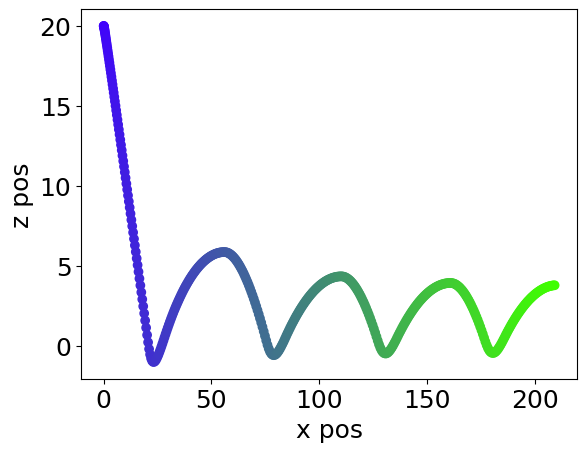

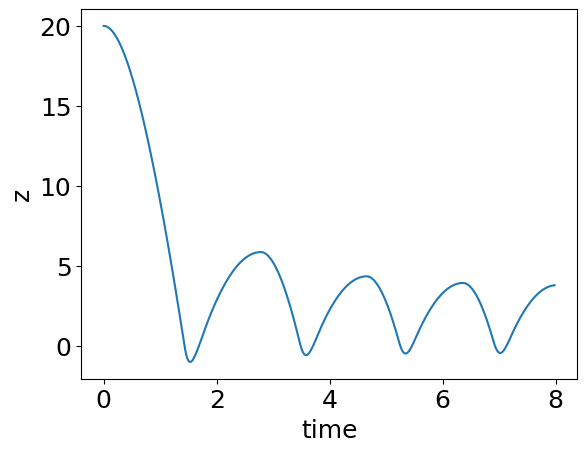

In [117]:
fig = plt.figure()

num = len(result[:, 0])
colors = [ (.25 , i / num , 1 - i / num ) for i in range(num) ]

ax = fig.add_subplot(111)
ax.scatter(result[:, 0], result[:, 2], c=colors)
ax.set_xlabel('x pos')
ax.set_ylabel('z pos')

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(tsim, result[:,2])
ax1.set_xlabel('time')
ax1.set_ylabel('z')

### Get the results from simulating with pybounds

In [118]:
simulator = pybounds.Simulator(f_sigm_combined_nonlinear, h_three_states, dt=delta_t,
                                state_names=['x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot', 'm', 'e', 'mu'], input_names=['f_x', 'f_z', 'tor'], measurement_names=['x', 'z', 'theta_dot'], mpc_horizon=int(1/delta_t))

In [125]:
# this might be an unecessary fix but I was getting index out of bounds for no reason
simulator.setpoint = { i : np.array([0]*int(8/delta_t)) for i in simulator.state_names }

cur_time = delta_t
u_np = []

while cur_time < 8:
    index = len(u_np)

    u_t = go_right_controller(result[index], cur_time)
    u_np.append(u_t)
    cur_time += delta_t

up_np = np.array(u_np)
print(up_np.shape)

(400, 3)


In [126]:
import pandas as pd

u_sim_df = pd.DataFrame(u_np, columns=['f_x', 'f_z', 'tor'])
x_sim_df = pd.DataFrame(result, columns=['x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot', 'm', 'e', 'mu'])

In [127]:
# Set initial state
x0 = x_sim_df.iloc[0]

open_loop_sim_y = np.array([x_sim_df['x'], x_sim_df['z'], x_sim_df['theta_dot']])
print(tsim.shape)

(400,)


Text(0, 0.5, 'z')

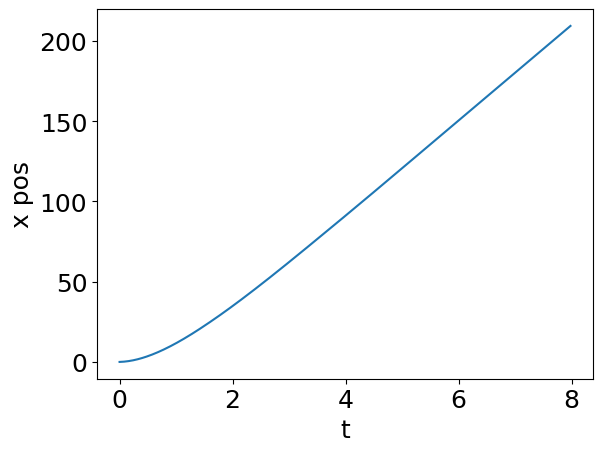

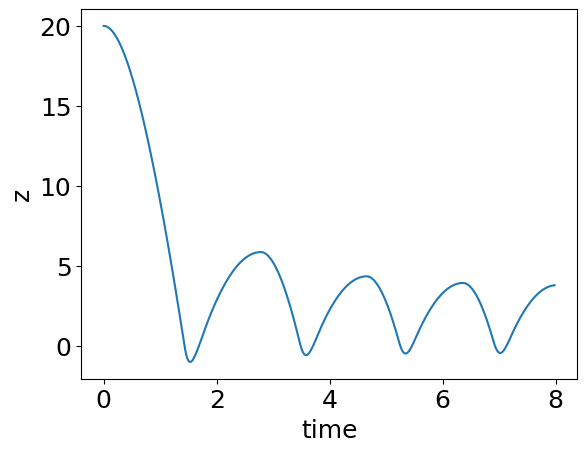

In [128]:
# Plot the x component -- it should match what we had above
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(tsim, open_loop_sim_y[0])
ax.set_xlabel('t')
ax.set_ylabel('x pos')

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(tsim, open_loop_sim_y[1])
ax1.set_xlabel('time')
ax1.set_ylabel('z')

In [131]:
# Write as a function so we can reuse it
def perturb_state_and_simulate(simulator, state_to_perturb, plot=False):
    # Perturbation amount (should be small, but exact value does not matter much)
    eps = 1e-1

    # Perturbation vector
    e_vec = np.zeros((x_sim_df.shape[1]))
    e_vec[state_to_perturb] = eps

    # Perturb in positive direction
    x0 = x_sim_df.iloc[0] + e_vec
    open_loop_sim_plus = simulator.simulate(x0=x0, u=u_sim_df.values, return_full_output=True)
    open_loop_sim_y_plus = {'x': open_loop_sim_plus[1]['x'], 'z': open_loop_sim_plus[1]['z'], 'theta_dot': open_loop_sim_plus[1]['theta_dot']}

    # Perturb in negative direction
    x0 = x_sim_df.iloc[0] - e_vec
    open_loop_sim_minus = simulator.simulate(x0=x0, u=u_sim_df.values, return_full_output=True)
    open_loop_sim_y_minus = {'x': open_loop_sim_minus[1]['x'], 'z': open_loop_sim_minus[1]['z'], 'theta_dot': open_loop_sim_minus[1]['theta_dot']}

    # Plot the measurements for the positive and negative perturbation
    if plot:
      measurement_to_show = 'x'
      plt.plot(tsim, open_loop_sim_y_plus[measurement_to_show], color='red')
      plt.plot(tsim, open_loop_sim_y_minus[measurement_to_show], color='blue')
      plt.xlabel('Time, sec')
      plt.ylabel(measurement_to_show)

    return open_loop_sim_y_plus, open_loop_sim_y_minus

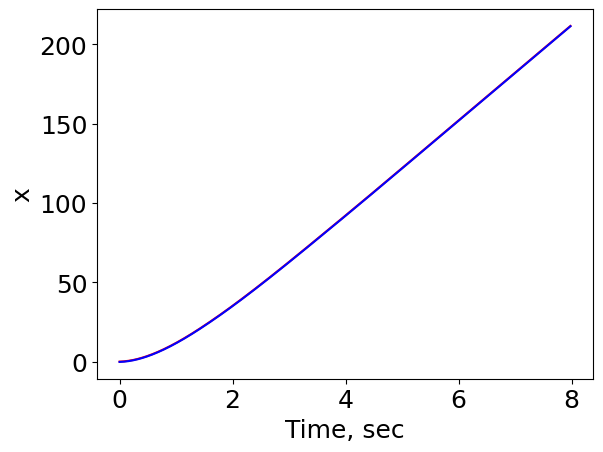

In [132]:
state_to_perturb = 0
open_loop_sim_y_plus, open_loop_sim_y_minus = perturb_state_and_simulate(simulator, state_to_perturb, plot=True)

In [133]:
O = []
for i in range(x_sim_df.shape[1]):
  open_loop_sim_y_plus, open_loop_sim_y_minus = perturb_state_and_simulate(simulator, i)
  dY_dxi = np.ravel(pd.DataFrame(open_loop_sim_y_plus).values) - np.ravel(pd.DataFrame(open_loop_sim_y_minus).values)
  O.append(dY_dxi)
O = np.vstack(O).T

In [134]:
W_o = O.T@O

/tmp/ipykernel_162385/4209761820.py:3: RuntimeWarning: invalid value encountered in log
  img = plt.imshow(np.log(Finv), origin='upper')


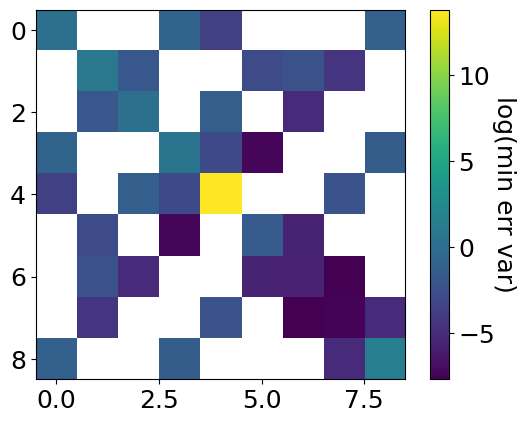

In [135]:
lam = 1e-6
Finv = np.linalg.inv(W_o + lam*np.eye(len(W_o)))
img = plt.imshow(np.log(Finv), origin='upper')

# Add the colorbar, referencing the AxesImage object 'im'
cbar = plt.colorbar(img)
cbar.set_label('log(min err var)', rotation=270, labelpad=15)

In [139]:
# Construct O in sliding windows
SEOM = pybounds.SlidingEmpiricalObservabilityMatrix(simulator, tsim, x_sim_df, u_sim_df, w=20, eps=1e-4)

# Get O's
O_sliding = SEOM.get_observability_matrix()

In [140]:
measurement_noise_vars = {key: val**2 for key, val in measurement_noise_stds.items()}

In [141]:
# Compute the Fisher information & Chernoff inverse
FO = pybounds.FisherObservability(SEOM.O_df_sliding[0], measurement_noise_vars, lam=1e-8)

In [142]:
# Get the Fisher information, inverse, and R matrix
F, F_inv, R = FO.get_fisher_information()
F_inv

,x,x_dot,z,z_dot,theta,theta_dot,m,e,mu
x,1.313796e-02,-1.276203e-01,-3.575752e-03,5.676576e-02,0.0,1.033434e-26,-1.992430e-02,0.0,0.0
x_dot,-1.276203e-01,1.868717e+00,6.203362e-02,-9.847959e-01,-0.0,-1.619030e-25,3.456549e-01,-0.0,-0.0
z,-3.575752e-03,6.203362e-02,9.668039e-03,-6.412342e-02,0.0,-7.263439e-27,1.247844e-02,0.0,0.0
z_dot,5.676576e-02,-9.847959e-01,-6.412342e-02,7.147707e-01,0.0,9.734908e-26,-1.980977e-01,0.0,0.0
theta,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,100000000.0,0.000000e+00,0.000000e+00,0.0,0.0
theta_dot,1.033434e-26,-1.619030e-25,-7.263439e-27,9.734908e-26,0.0,5.000000e-04,-3.098475e-26,0.0,0.0
m,-1.992430e-02,3.456549e-01,1.247844e-02,-1.980977e-01,0.0,-3.098475e-26,6.953061e-02,0.0,0.0
e,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,100000000.0,0.0
mu,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,100000000.0


In [143]:
# Choose sensors to use from O -- you can select a subset from the available measurements
o_sensors = ['x', 'z', 'theta_dot']

# Chose states to use from O
o_states = ['x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot', 'm', 'e', 'mu']

# Choose time-steps to use from O
window_size = 6 # this cannot be larger than what was defined above
o_time_steps = np.arange(0, window_size, step=1)

# Redefine R -- if you remove a sensor you need to change R
o_measurement_noise_vars = {key: measurement_noise_vars[key] for key in o_sensors}
o_sensors

['x', 'z', 'theta_dot']

In [144]:
# Compute the Fisher information & inverse for each window and store the minimum error variance
SFO = pybounds.SlidingFisherObservability(SEOM.O_df_sliding, time=SEOM.t_sim, lam=1e-8, R=o_measurement_noise_vars,
                                 states=o_states, sensors=o_sensors, w=None)

In [145]:
# Pull out minimum error variance, 'time' column is the time vector shifted forward by w/2 and 'time_initial' is the original time
EV_aligned = SFO.get_minimum_error_variance()

In [146]:
EV_no_nan = EV_aligned.fillna(method='bfill').fillna(method='ffill')

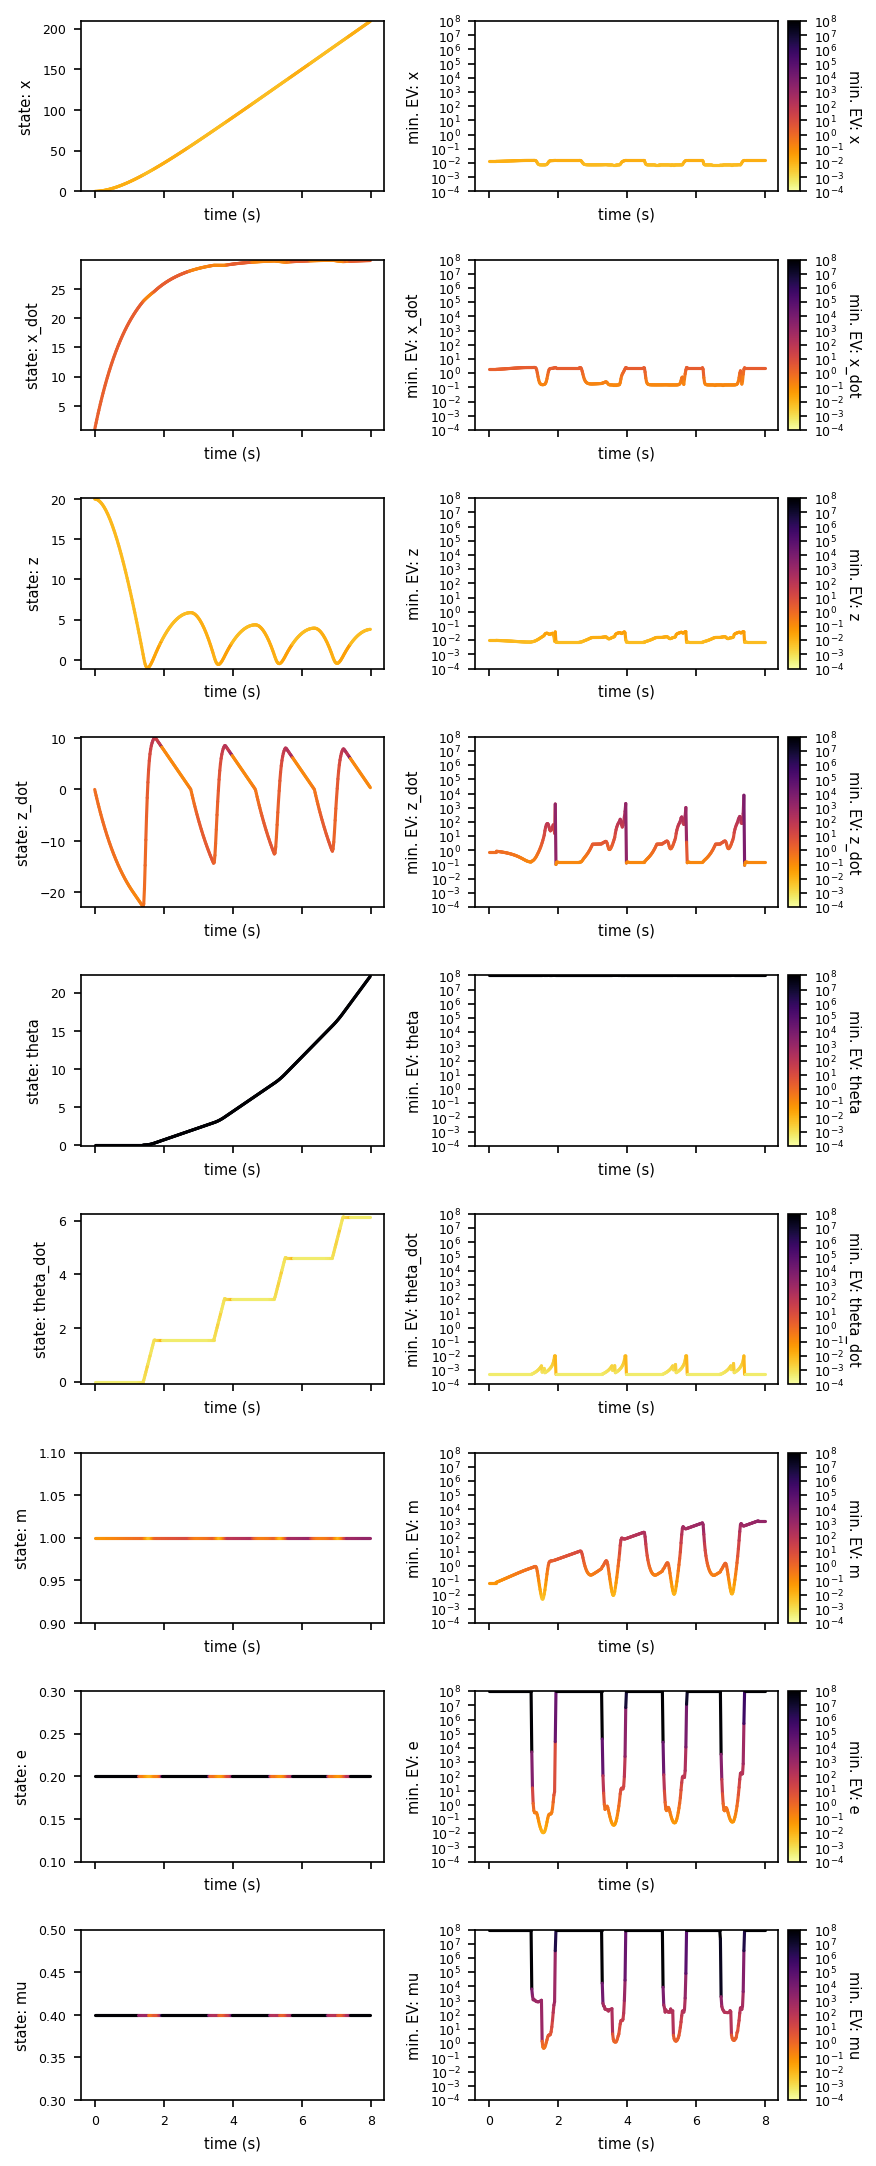

In [148]:

import matplotlib as mpl
x_sim = x_sim_df
t_sim = tsim

states = list(SFO.FO[0].O.columns)
n_state = len(states)

fig, ax = plt.subplots(n_state, 2, figsize=(6, n_state*2), dpi=150, sharex=True)
ax = np.atleast_2d(ax)

cmap = 'inferno_r'

min_ev = np.min(EV_no_nan.iloc[:, 2:].values)
max_ev = np.max(EV_no_nan.iloc[:, 2:].values)

log_tick_high = int(np.ceil(np.log10(max_ev)))
log_tick_low = int(np.floor(np.log10(min_ev)))
cnorm = mpl.colors.LogNorm(10**log_tick_low, 10**log_tick_high)

for n, state_name in enumerate(states):
    pybounds.colorline(t_sim, x_sim[state_name], EV_no_nan[state_name].values, ax=ax[n, 0], cmap=cmap, norm=cnorm)
    pybounds.colorline(t_sim, EV_no_nan[state_name].values, EV_no_nan[state_name].values, ax=ax[n, 1], cmap=cmap, norm=cnorm)

    # Colorbar
    cax = ax[n, -1].inset_axes([1.03, 0.0, 0.04, 1.0])
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap), cax=cax,
                        ticks=np.logspace(log_tick_low, log_tick_high, log_tick_high-log_tick_low + 1))
    cbar.set_label('min. EV: ' + state_name, rotation=270, fontsize=7, labelpad=8)
    cbar.ax.tick_params(labelsize=6)

    x_max = np.max(x_sim[state_name])
    x_min = np.min(x_sim[state_name])

    ax[n, 0].set_ylim(x_min - 0.1, x_max + 0.1)
    ax[n, 0].set_ylabel('state: ' + state_name, fontsize=7)

    ax[n, 1].set_ylim(10**log_tick_low, 10**log_tick_high)
    ax[n, 1].set_yscale('log')
    ax[n, 1].set_ylabel('min. EV: ' + state_name, fontsize=7)
    ax[n, 1].set_yticks(np.logspace(log_tick_low, log_tick_high, log_tick_high-log_tick_low + 1))

for a in ax.flat:
    a.tick_params(axis='both', labelsize=6)
    a.set_xlabel('time (s)', fontsize=7)
    offset = t_sim[-1] * 0.05
    a.set_xlim(-offset, t_sim[-1] + offset)

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.4)